# PRINCIPIOS DE MACHINE LEARNING
## PROYECTO 1
### SERGIO MASSO GIRALDO
### UNIVERSIDAD DE LOS ANDES

# La tarea de regresión: Modelos polinomiales y regularizados

## Movilidad sostenible
Actualmente, estamos ante la presencia de una variedad de fenómenos que afectan el medio ambiente y se reflejan en el calentamiento global, la contaminación del aire y la pérdida de biodiversidad, entre otros.  
Establecer políticas que ataquen sus causas y desarrollar planes de gestión de riesgos que mitiguen sus efectos y permitan accionar oportunamente es uno de los grandes retos a los que nos enfrentamos como sociedad.  

Uno de estos problemas está relacionado con el **cambio climático**, el cual se refiere tanto al calentamiento global provocado por la emisión de gases de efecto invernadero, como al aumento de los desastres ambientales inducidos por dicho calentamiento.  

En particular, en el caso del dióxido de carbono (CO2), aunque es necesario para la vida, su exceso de concentración contribuye significativamente al efecto invernadero, elevando la temperatura del planeta y desequilibrando el ciclo natural.  

Una manera de reducir las emisiones de CO2 es fomentar planes de **movilidad sostenible**, entendida como la capacidad de realizar traslados de personas o mercancías con seguridad y sin afectar la salud ni los ecosistemas.  
Apoyar e incentivar medidas de movilidad sostenible, como el uso de vehículos eléctricos y bicicletas, contribuiría en gran medida a paliar este problema.  

En este contexto, el problema que se va a abordar es cómo construir un **modelo predictivo** que permita determinar la demanda sobre el uso de un sistema de alquiler de bicicletas. Este conocimiento puede dar soporte para mejorar el servicio y conocer los factores que inciden en su eficiencia.  

---

## Objetivos
- Aplicar técnicas de regresión para construir un modelo predictivo que estime la demanda en el sistema de alquiler de bicicletas, siguiendo el ciclo completo de *machine learning*.  
- Identificar los factores que más influyen en la demanda a partir del análisis de los datos disponibles.  

---

## Conjunto de Datos
- El conjunto de datos contiene información sobre la cantidad de bicicletas rentadas en distintos períodos de tiempo, junto con variables relacionadas con condiciones meteorológicas y aspectos de temporalidad.  
- Como primer paso, es fundamental revisar el **diccionario de datos** para comprender la naturaleza y el significado de cada variable.  
- Los datos originales provienen de un enlace externo y han sido **modificados** con fines específicos para este proyecto.  yecto.  
s de este proyecto.

### Importacion de Librerias necesarias

In [107]:
# Instalacion de librerias
%pip install --upgrade pip
%pip install pandas
%pip install numpy
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.




In [1]:
# Importación de librerías principales
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, RobustScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, KFold

# Configuración de estilo para gráficos
plt.style.use("seaborn-v0_8")
sns.set_theme()

print("Librerías importadas correctamente")

Librerías importadas correctamente


### Extraccion de datos

In [3]:
# Funcion para extraer los datos desde un orgigen Data/.csv

def extraer_data(nombre_archivo: str, ruta: str = ".") -> pd.DataFrame:
    """
    Función para leer archivos (CSV, Excel) usando rutas relativas o absolutas.
    Parámetros:
    - nombre_archivo: nombre del archivo con extensión (ej: 'datos.csv')
    - ruta: ruta relativa o absoluta donde está el archivo (por defecto el directorio actual)
    Retorna:
    - DataFrame con el contenido del archivo
    """
    # Ruta completa
    ruta_completa = os.path.join(ruta, nombre_archivo)
    
    if not os.path.exists(ruta_completa):
        raise FileNotFoundError(f"El archivo {ruta_completa} no existe.")
    
    # Detectar extensión y leer según corresponda
    extension = os.path.splitext(nombre_archivo)[1].lower()
    
    if extension == ".csv":
        df = pd.read_csv(ruta_completa)
    elif extension in [".xls", ".xlsx"]:
        df = pd.read_excel(ruta_completa)
    else:
        raise ValueError(f"Formato {extension} no soportado. Usa CSV o Excel.")
    
    return df

archivo = 'ETYT2_6WS-GwUXGPSWerJQ_c011f04f69254a4087d4396a2e4307f1_Datos_Etapa-1.csv'
ruta_data = "C:\\Users\\masso\\Universidad\\UNIVERSIDAD LOS ANDES\\MACHINE LEARNING DEEPLEARNING IA\\Data"
data = extraer_data(archivo,ruta_data)

if data.empty:
    print('El DataFrame está vacío.') # Se valida si se leyo o no el df
else:
    print(f'El DataFrame tiene {data.shape}')


El DataFrame tiene (17379, 9)


In [6]:
# Visualizacion de los datos
data.head(5)

,season,weekday,weathersit,temp,atemp,hum,windspeed,cnt,time_of_day
0,Winter,6,Clear,3.28,3.0014,0.81,0.0,16,Night
1,Winter,6,Clear,2.34,1.9982,0.80,0.0,40,Night
2,Winter,6,Clear,2.34,1.9982,0.80,0.0,32,Night
3,Winter,6,Clear,3.28,3.0014,0.75,0.0,13,Night
4,Winter,6,Clear,3.28,3.0014,0.75,0.0,1,Night


# EDA: Entendiendo los datos...
De acuerdo con la problematica planteada en el proyecto se inicializa con una visualizacion completa y entendimiento de los datos aportados, buscando datos nulos, faltantes, errados o atipicos para aplicar tecnicas en los mismos y presentar una data limpia en la implementacion del modelo

"Exploración y perfilamiento de los datos, utilizando las funcionalidades de la librería pandas. Recuerda que este paso es muy importante para determinar problemas de calidad (por ejemplo, valores ausentes y registros duplicados) y tomar decisiones relacionadas con la preparación de los datos para el algoritmo de aprendizaje. Limpieza y preparación de los datos, justificando las decisiones tomadas con base en los resultados obtenidos en el paso anterior."

In [9]:
data.isna().sum() # Funcion nos permite ver la cantidad de datos nulos por variable

season         0
weekday        0
weathersit     0
temp           0
atemp          0
hum            0
windspeed      0
cnt            0
time_of_day    0
dtype: int64

No se encuentran valores faltantes o nulos en el Dataframe

In [12]:
data.duplicated().sum() 

42

Se encuentra evidencia de que hay valores duplicados en este caso se encuentran 42 valores duplicados en el Dataframe

In [15]:
columnas = data.columns
for i in columnas:
    print(f'Mostrando lo datos unicos de la columna {i}')
    print(data[i].unique())


Mostrando lo datos unicos de la columna season
['Winter' 'Spring' 'Summer' 'Fall']
Mostrando lo datos unicos de la columna weekday
[6 0 1 2 3 4 5]
Mostrando lo datos unicos de la columna weathersit
['Clear' 'Mist' 'Light Rain' 'Heavy Rain']
Mostrando lo datos unicos de la columna temp
[ 3.28  2.34  1.4   7.04  9.86  8.92 11.74 13.62 12.68 10.8   7.98  6.1
  4.22 -0.48 -1.42  0.46 -2.36  5.16 -3.3  -4.24 -5.18 -6.12 -7.06 16.44
 18.32 19.26 20.2  14.56 17.38 15.5  23.02 22.08 21.14 23.96 24.9  26.78
 27.72 25.84 28.66 30.54 29.6  32.42 33.36 34.3  31.48 35.24 36.18 37.12
 38.06 39.  ]
Mostrando lo datos unicos de la columna atemp
[ 3.00140e+00  1.99820e+00  1.00160e+00  7.00100e+00  9.99740e+00
  5.99780e+00  1.19972e+01  1.39970e+01  1.30004e+01  1.10006e+01
 -9.98200e-01 -2.00140e+00 -2.99800e+00 -4.99780e+00 -6.99760e+00
 -8.99740e+00 -8.00080e+00 -4.00120e+00 -1.60000e-03 -6.00100e+00
  5.00120e+00 -1.20004e+01 -1.09972e+01 -1.00006e+01  3.99800e+00
 -1.40002e+01 -1.29970e+01 -1.600

No se encuentra valores con el mismo significado pero tipificadores diferentes, solo evidenciamos que la columna weekday deberia de empezar en 1 hasta 7 pero empieza dese 0 hasta el 6

In [18]:
# Descripcion de los datos:
data.describe()

,weekday,temp,atemp,hum,windspeed,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,3.003683,15.358397,15.401157,0.627229,12.736540,189.463088
std,2.005771,9.050138,11.342114,0.192930,8.196795,181.387599
min,0.000000,-7.060000,-16.000000,0.000000,0.000000,1.000000
25%,1.000000,7.980000,5.997800,0.480000,7.001500,40.000000
50%,3.000000,15.500000,15.996800,0.630000,12.998000,142.000000
75%,5.000000,23.020000,24.999200,0.780000,16.997900,281.000000
max,6.000000,39.000000,50.000000,1.000000,56.996900,977.000000


Podemos ver que hay valores atipicos para algunas variables numericas como lo es en cnt puede haberse presentado ventas de 977 en un solo dia y que la media de venta en todos los datos presentados es de 189 por dia

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       17379 non-null  object 
 1   weekday      17379 non-null  int64  
 2   weathersit   17379 non-null  object 
 3   temp         17379 non-null  float64
 4   atemp        17379 non-null  float64
 5   hum          17379 non-null  float64
 6   windspeed    17379 non-null  float64
 7   cnt          17379 non-null  int64  
 8   time_of_day  17379 non-null  object 
dtypes: float64(4), int64(2), object(3)
memory usage: 1.2+ MB


Hay valores muy altos en algunos casos como lo pueden ser en cnt o windspeed adicional se evidencia valores categoricos que para aplicar un modelo de regresion estas variables deben de pasar a ser numericas para poder aportar valor al modelo en si

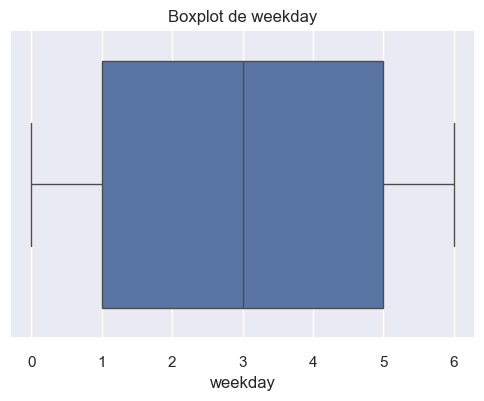

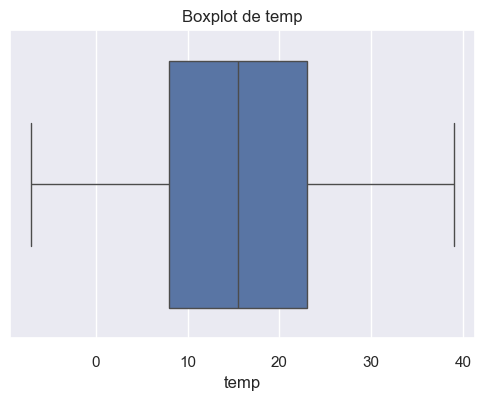

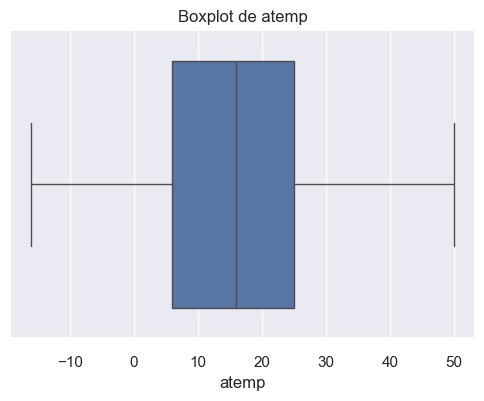

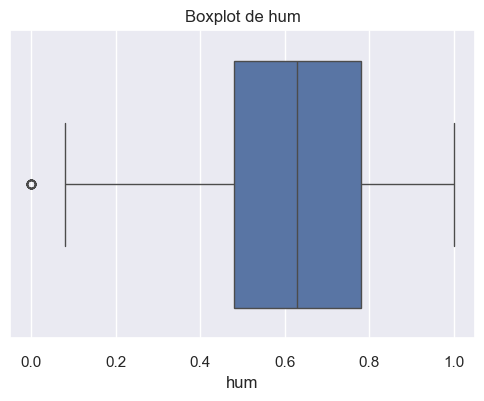

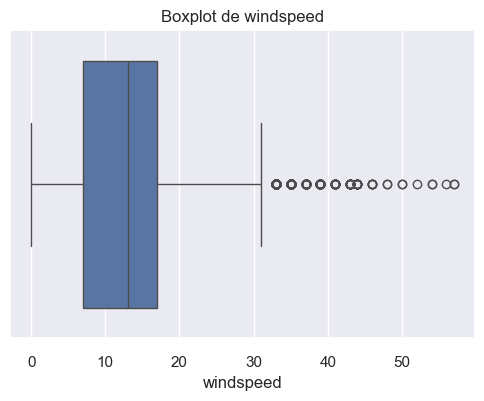

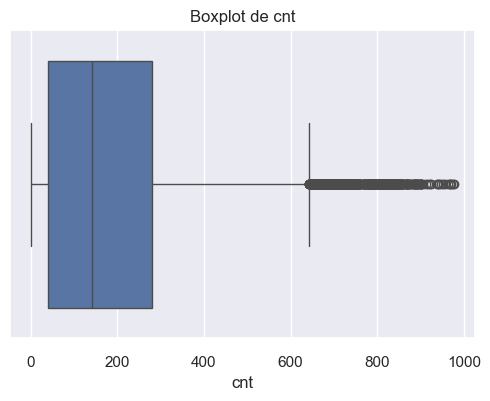

In [24]:
# Creacion de graficos para valores atipicos en variables numericas
num_vars = ['weekday','temp','atemp','hum','windspeed','cnt']

for col in num_vars:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot de {col}')
    plt.show()


Como se evidencia en el diagrama de cajas, para cada variable se identifican valores atípicos en `hum`, `windspeed` y `cnt`. Aunque estos valores podrían ser normales dentro del contexto específico del entorno analizado, es recomendable aplicar técnicas de estandarización. Esto permitirá que el modelo no se vea sesgado ni otorgue un peso desproporcionado a dichos valores atípicos.

Además, es importante analizar la correlación entre estas variables para obtener una mejor comprensión de sus relaciones y evaluar, idealmente con el apoyo de un experto en el dominio, si estos valores tienen sentido en la práctica o si representan anomalías reales.
    
Dado que no se cuenta con la asesoría de un experto en este momento, no se eliminarán los valores atípicos. En su lugar, se procederá a aplicar técnicas de estandarización para poder trabajar con ellos de manera adecuada dentro del modelo.

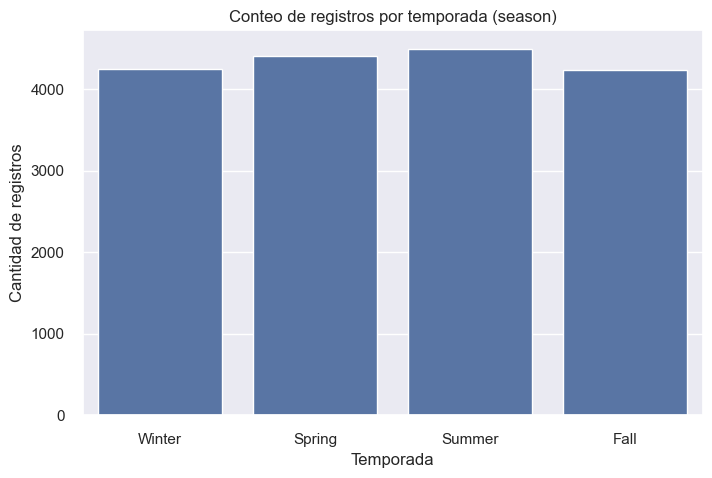

In [27]:
# Gráfico de barras del promedio de cnt por temporada
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='season')
plt.title('Conteo de registros por temporada (season)')
plt.xlabel('Temporada')
plt.ylabel('Cantidad de registros')
plt.show()

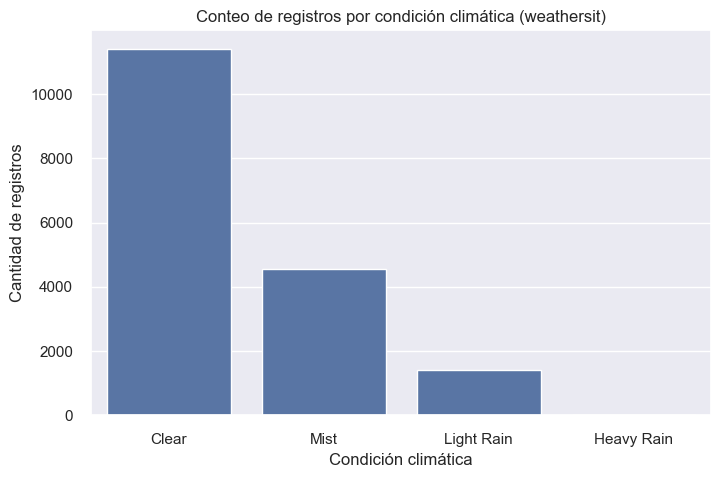

In [29]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='weathersit')
plt.title('Conteo de registros por condición climática (weathersit)')
plt.xlabel('Condición climática')
plt.ylabel('Cantidad de registros')
plt.show()

Finalizando con el entendimiento de los datos se evidencia que hay mayor numero de bicicletas rentadas cuando la condicion climatica esta despejada seguido de esta con una niebla y muy rara vez pero presente con lluvia, adicional que verano y primavera son las temporadas con mayor numero de renta de bicicletas

# Transformacion de los datos

Durante el proceso de preparación se realizará la transformación de los datos con el objetivo de obtener un conjunto limpio y adecuado para los modelos de regresión que se van a implementar.

- **Variables categóricas:** dado que los algoritmos de regresión requieren variables numéricas, las variables categóricas serán convertidas mediante codificación *dummy* (One-Hot Encoding). Esto generará nuevas columnas binarias que representarán cada categoría y permitirá al modelo utilizarlas correctamente.

- **Duplicados:** se eliminarán los registros duplicados para garantizar la calidad y consistencia del dataset.

- **Variable `weekday`:** se ajustará la numeración de esta variable para que siga el rango correcto de 1 a 7, correspondiente a los días de la semana.

- **Valores faltantes:** no se evidencian valores nulos en el conjunto de datos, por lo que no es necesario aplicar técnicas de imputación.

- **Escalado de variables numéricas:** se aplicará un proceso de escalado a las variables numéricas con el fin de mitigar el impacto de valores atípicos y evitar que el modelo otorgue un peso desproporcionado a ciertas variables frente a otras.

Con estas transformaciones se asegura que el dataset esté en condiciones óptimas para la construcción y evaluación de los modelos de regresión.

In [33]:
# Se genera la copia del dataset inicial en un nuevo DataFrame para la transformacion
df = data.copy()

In [35]:
# Ajustar la columna weekday para que vaya de 1 a 7
df["weekday"] = df["weekday"] + 1
df["weekday"].unique()

array([7, 1, 2, 3, 4, 5, 6], dtype=int64)

In [37]:
# Eliminacion de duplicados 
df = df.drop_duplicates()
df.duplicated().sum()

0

In [39]:
df.shape

(17337, 9)

## Regresión polinomial

Con el conjunto de datos preparado, vamos a entrenar un modelo de regresión polinomial multivariable. De acuerdo con el enunciado a la problematica: "Para determinar el grado de la transformación polinomial emplea las técnicas de selección de modelos sobre los siguientes valores de grado de polinomio: [2, 3]. Utiliza para la selección la métrica RMSE." empezaremos con un degree de 2 y luego pasaremos a realizar la evalucion con un degree 3

"Construcción de un modelo de regresión polinomial. Para determinar el grado de la transformación polinomial emplea las técnicas de selección de modelos sobre los siguientes valores de grado de polinomio: [2, 3]. Utiliza para la selección la métrica RMSE."

In [103]:
# Separar variables
X = df.drop('cnt', axis=1) # Variables predictoras 
y = df['cnt'] # Variable objetivo

# División train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=77)

De la libreria de `sklearn` se hace uso del `tran_test_split` que sirve para realizar la separacion de los datos en este caso se pasa de una vez X y y que ya estaba separados y se hace la creacion de los conjuntos de datos a usar en el proyecto como lo son: `X_train, X_test, y_train, y_test` el uso de esta libreria permite inidicar el tamaño se separacion en este caso se esta usando 80% para entrenamiento y 20% para pruebas el `random_state` sirve para crea una semilla y que los resultados no cambien si se vuelve a usar

In [106]:
# Codificación categóricas dummies
X_train = pd.get_dummies(X_train, columns=['weekday','season','weathersit','time_of_day'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['weekday','season','weathersit','time_of_day'], drop_first=True)

# Alinear columnas (por si faltan categorías en test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

En este caso se hace la modificacion y transformacion de las variables categoricas a numericas aunque `get_dummies` no es muy usado en produccion o en pipelines es util para este modelo o proyecto ejemplo (Lo ideal seria usar `OneHotEncoder` - aunque es mas detallado en los modulos o semanas siguientes a esta entrega) con `get_dummies` se le indica a que variables se le debe de crear las columnas nuevas lo cual devuelve automaticamente un DataFrame

`get_dummies` cumple con el papel para modificar o transformar los datos dando el mismo resultado que al usar `OneHotEncoder`

A continuacion se realizara la creacion de los modelos por separado para ver mas a detalle cada metrica entregada por cada modelo y su grado relacionado

In [111]:
# Creacion de Polinomio grado 2
pf_2 = PolynomialFeatures(degree=2) # Grado 2
x_train_pol2 = pf_2.fit_transform(X_train) # Entrenamiento con x_train usando la variable que cuenta ya con PolynomialFeatures
x_train_pol2.shape # Mostramos el tamaño nuevo del df para ver cuantas variables nuevas creo el modelo

(13869, 190)

In [113]:
# Escalado numéricas
# Escalado del dataset - al ser para una regresion polinomial y lasso este proceso puede ser sensible por lo cual es mejor usar StandarScaler o RobustScaler
scaler = RobustScaler()
x_train_pol2 = scaler.fit_transform(x_train_pol2)

Principalmente se hace el uso del `RobustScaler` por motivos de que se encuentran con outliers y este metodo de escalado de `scikit-learn` es util para estos, pues `StandardScaler` usa media y desviación lo cual puede llegar a ser muy sensible y `RobustScaler` ignora extremos, adicional que es ideal para Lasso el cual se usara mas adelante. (Se realizo la prueba con StandardScaler y RobustScaler da mejor resultados)

In [116]:
# Entrenamiento del modelo:
reg_polinomial = LinearRegression().fit(x_train_pol2, y_train)

In [117]:
x_test_pol2 = pf_2.transform(X_test)
x_test_pol2 = scaler.transform(x_test_pol2)

Aquí estoy aplicando al conjunto de test las mismas transformaciones polinomiales y el mismo escalado aprendidos en el entrenamiento, sin introducir fuga de información.

In [121]:
y_pred = reg_polinomial.predict(x_test_pol2)

print(f'------ Modelo de regresión polinomial grado 2 ----')
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f'R²: {r2_score(y_test, y_pred):.2f}')

------ Modelo de regresión polinomial grado 2 ----
RMSE: 134.62
MAE: 98.84
R²: 0.46


El modelo de regresión polinomial tiene un valor de R<sup>2</sup> (0.45) y un RMSE y MAE de 99 y 135, el generar combinaciones polinomiales aumenta la complejidad del modelo, es decir, se aumenta el número de variables independientes para realizar el proceso de regresión. Por lo tanto, pasaremos a realizar el proceso con un degree de 3 crearemos un nuevo objeto de la clase `PolynomialFeatures` y lo almacenaremos en la variable `pf_3`:

In [124]:
pf_3 = PolynomialFeatures(degree=3)

In [126]:
x_train_pol3 = pf_3.fit_transform(X_train)

In [127]:
scaler_2 = RobustScaler()
x_train_pol3 = scaler_2.fit_transform(x_train_pol3)

In [129]:
x_train_pol3.shape

(13869, 1330)

In [130]:
%%time
reg_polinomial = LinearRegression(n_jobs=-1).fit(x_train_pol3, y_train)

CPU times: total: 18.2 s
Wall time: 5.73 s


In [131]:
x_test_pol3 = pf_3.transform(X_test)

In [132]:
x_test_pol3 = scaler_2.transform(x_test_pol3)

In [133]:
y_pred = reg_polinomial.predict(x_test_pol3)

print(f'------ Modelo de regresión polinomial grado 3 ----')
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f'R²: {r2_score(y_test, y_pred):.2f}')

------ Modelo de regresión polinomial grado 3 ----
RMSE: 130.39
MAE: 94.09
R²: 0.49


Se entrenaron dos modelos de regresión polinomial, uno de grado 2 y otro de grado 3, evaluados con las métricas RMSE, MAE y R².

El modelo de grado 3 presenta un mejor desempeño general frente al de grado 2.
- El RMSE disminuye de 134.62 a 130.39, lo que indica que el error cuadrático medio es menor y el modelo comete errores grandes con menor frecuencia.
- El MAE se reduce de 98.84 a 94.09, lo que significa que, en promedio, las predicciones del modelo de grado 3 están más cerca del valor real.
- El R² aumenta de 0.46 a 0.49, indicando que el modelo de grado 3 explica un mayor porcentaje de la variabilidad de la variable objetivo.

El modelo polinomial de grado 3 se selecciona por presentar menores errores y mayor poder explicativo, indicando una mejor representación de la no linealidad de los datos.

Ahora se volvera a realizar todo el mismo proceso pero aplicando un pipeline para todo el modelo lo cual lo hace mas rapido en la busqueda del mejor grado para el modelo polinomial

### Búsqueda de hiperparámetros
Queremos encontrar un valor que resulte en el mejor desempeño posible. Podemos automatizar el proceso de búsqueda de hiperparámetros mediante la clase `GridSearchCV`, que entrena múltiples modelos y retorna el que tiene mejor desempeño.

In [139]:
# Creacion de Pipeline
polynomial_regression = make_pipeline(
    PolynomialFeatures(),
    RobustScaler(),
    LinearRegression()
)

In [140]:
# Busqueda del mejor grado polinomial
param_grid = {'polynomialfeatures__degree': [2, 3]} # grados a pasar al modelo
kfold = KFold(n_splits=10, shuffle=True, random_state=77) # metodo de validacion cruzada
modelos_grid = GridSearchCV(polynomial_regression, param_grid, cv=kfold, n_jobs=-1) # Creacion de variable para luego entrenar y testear
modelos_grid.fit(X_train, y_train)
print("Mejor parámetro: ", modelos_grid.best_params_)
mejor_modelo = modelos_grid.best_estimator_

y_pred_poly = mejor_modelo.predict(X_test)
rmse_poly = mean_squared_error(y_test, y_pred_poly, squared=False)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f'------ Mejor modelo de regresión polinomial ----')
print(f"RMSE: {rmse_poly:.2f}")
print(f"MAE: {mae_poly:.2f}")
print(f'R²: {r2_poly:.2f}')
print(f'------------------------------------------------')

Mejor parámetro:  {'polynomialfeatures__degree': 3}
------ Mejor modelo de regresión polinomial ----
RMSE: 130.39
MAE: 94.09
R²: 0.49
------------------------------------------------


C:\Users\masso\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Esto nos confirma lo antes dicho el mejor modelo es el modelo con grado 3

## Regresión Lasso
"Construcción de un modelo de regresión regularizada Lasso. Para determinar el valor del hiperparámetro de regularización utiliza las técnicas de selección de modelos sobre los siguientes valores para α: [1, 2, 3, 4, 5]. Utiliza para la selección la métrica RMSE."

In [71]:
# Division de los datos en entrenamiento y prueba
train, test = train_test_split(df, test_size=0.2, random_state=77)
x_train = train.drop(['cnt'],axis=1)
y_train = train['cnt']
x_test = test.drop(['cnt'], axis=1)
y_test = test['cnt']

De la libreria de sklearn se hace uso del tran_test_split que sirve para realizar la separacion de los datos en este caso se pasa de una vez X y y que ya estaba separados y se hace la creacion de los conjuntos de datos a usar en el proyecto como lo son: train, test, el uso de esta libreria permite inidicar el tamaño se separacion en este caso se esta usando 80% para entrenamiento y 20% para pruebas el random_state sirve para crea una semilla y que los resultados no cambien si se vuelve a usar

In [74]:
# Codificacion de variables categoricas a dummies
x_train = pd.get_dummies(x_train,columns=['weekday','season', 'weathersit', 'time_of_day'], drop_first=True)
x_test = pd.get_dummies(x_test,columns=['weekday','season', 'weathersit', 'time_of_day'], drop_first=True)
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)
columns = x_train.columns

In [76]:
# Despues de separado el conjunto de datos estandarizamos los datos por lo antes dicho:
scaler_lasso = RobustScaler() 
x_train = scaler_lasso.fit_transform(x_train)
x_train = pd.DataFrame(x_train, columns=columns)
x_test = scaler_lasso.transform(x_test)
x_test = pd.DataFrame(x_test,columns=columns)

In [92]:
# Definicion y creacion del modelo Lasso
lasso = Lasso()

# Definicion de alpha
param_grid = {'alpha':[1,2,3,4,5]}

# Creacion de Validacion cruzada con Kfold
Kfold = KFold(n_splits=10,shuffle=True,random_state=0) 
# útil para obtener una estimación del desempeño del modelo más realista que simplemente utilizando el conjunto de pruebas
# shuffle=True indica que se cambie el orden de los datos antes de separarlos en los grupos

Con base en el modelo Lasso determinar las variables más importantes para la predicción. 

In [96]:
# GridSearchCV para realizar la búsqueda exhaustiva del mejor hiperparámetro
modelos_grid = GridSearchCV(lasso, param_grid, cv=Kfold, n_jobs=-1,verbose=2)

# Entrenamiento del modelo
modelos_grid.fit(x_train, y_train)
print("------Mostrando el mejor alpha------")
print("Mejor parámetro: ", modelos_grid.best_params_)

print("------Mostrando los coeficientes del mejor modelo------")
mejor_modelo = modelos_grid.best_estimator_
pd.DataFrame(zip(x_train.columns, mejor_modelo.coef_),columns=["Variable","Coeficiente"])

Fitting 10 folds for each of 5 candidates, totalling 50 fits
------Mostrando el mejor alpha------
Mejor parámetro:  {'alpha': 1}
------Mostrando los coeficientes del mejor modelo------


,Variable,Coeficiente
0,temp,53.574129
1,atemp,42.257033
2,hum,-46.073909
3,windspeed,-0.000000
4,weekday_2,-0.000000
5,weekday_3,-0.000000
6,weekday_4,0.000000
7,weekday_5,0.000000
8,weekday_6,0.000000
9,weekday_7,0.000000


In [98]:
# Evalucion del modelo
# Variables para tabla comparativa
y_pred_lasso = mejor_modelo.predict(x_test)
rmse_lasso = mean_squared_error(y_test, y_pred_lasso, squared=False)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f'------ Modelo de regresión Lasso ----')
print(f"RMSE: {rmse_lasso:.2f}")
print(f"MAE: {mae_lasso:.2f}")
print(f'R²: {r2_lasso:.2f}')

------ Modelo de regresión Lasso ----
RMSE: 139.95
MAE: 103.62
R²: 0.42


C:\Users\masso\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Se pone el valor de alpha mas alto indicado en el ejercicio y evidenciamos como el coeficiente de algunas variables se vuelven 0 esto nos ayuda a establecer las variables más relevantes y entrenar un modelo diferente sobre el subconjunto de variables obtenido

## Tabla Comparativa
Elaboración de una tabla comparativa mostrando el rendimiento sobre test de los dos modelos seleccionados (con mejores rendimientos) de las actividades 3 y 4, con las métricas R2, RMSE y MAE.

In [148]:
resultados = pd.DataFrame({
    'Modelo': ['Regresión Lasso', 'Regresión Polinomial'],
    'RMSE': [rmse_lasso, rmse_poly],
    'MAE': [mae_lasso, mae_poly],
    'R²': [r2_lasso, r2_poly]
})

print(resultados.round(2))

                 Modelo    RMSE     MAE    R²
0       Regresión Lasso  139.95  103.62  0.42
1  Regresión Polinomial  130.39   94.09  0.49


# Análisis de resultados

**¿Cuál es el grado de la transformación polinomial que fue seleccionado utilizando la técnica de validación?**  
**R.** El grado seleccionado fue **3**, ya que el modelo de regresión polinomial con grado 2 obtuvo el mejor rendimiento en términos de RMSE durante la validación cruzada.

**¿Cuál fue el valor de α que fue seleccionado utilizando la técnica de validación para la regresión Lasso?**  
**R.** El valor de **α seleccionado fue 1**, ya que fue el que produjo el menor RMSE en la validación cruzada con `GridSearchCV`.

**A partir de la tabla comparativa, ¿Cuál modelo ofrece el mejor rendimiento sobre el conjunto test? ¿Qué interpretación puedes darles a los valores obtenidos sobre las métricas de rendimiento?**  
**R. Mejor modelo:** Regresión Polinomial  
**Interpretación:**
- El modelo polinomial tiene un menor RMSE y MAE, lo que indica que sus predicciones están más cerca de los valores reales en promedio.
- También tiene un R² más alto (0.49 vs 0.41), lo que significa que explica mejor la variabilidad de la demanda de bicicletas.
- Aunque la mejora no es drástica, sugiere que la relación entre las variables predictoras y la demanda no es completamente lineal, y que un modelo polinomial capta mejor esas interacciones.

**¿Cuáles variables fueron seleccionadas con el modelo Lasso?**  
**R.** Las variables con coeficientes distintos de cero son las que Lasso considera más relevantes para predecir la demanda. Si se coloca un alpha alto se puede visualizar que algunas variables cuentan con coeficientes igual a cero, pero si nos quedamos con el modelo ideal las variables relevantes serían las siguientes:
- `weekday`
- `temp`
- `hum`
- `season_Spring`
- `season_Summer`
- `season_Winter`
- `weathersit_Light Rain`
- `time_of_day_Morning`
- `time_of_day_Night`

**A partir de estas, ¿Qué interpretación de cara al problema puedes dar?**

- **temp (temperatura):** Tiene un coeficiente positivo alto, lo que indica que a mayor temperatura, mayor es la demanda de bicicletas. Esto sugiere que las personas prefieren usar bicicletas en climas agradables, lo cual es coherente con un uso recreativo o de transporte cómodo.
- **hum (humedad):** Coeficiente negativo, la humedad elevada reduce la demanda. Esto puede deberse a la incomodidad o al riesgo de lluvia, lo que desincentiva el uso de la bicicleta.
- **weekday (día de la semana):** Coeficiente positivo, los días laborales parecen tener mayor demanda, posiblemente por uso como medio de transporte hacia el trabajo o estudio.
- **weathersit_Light Rain:** Coeficiente negativo, la lluvia ligera reduce la demanda, lo cual es esperable por razones de seguridad y comodidad.
- **time_of_day_Morning** y **time_of_day_Night:** Ambos con coeficientes negativos, especialmente la noche. Esto sugiere que la mayoría de los viajes en bicicleta ocurren durante el día, posiblemente en horarios laborales o de ocio.

**Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.**

- **Planificación operativa:** Se puede ajustar la disponibilidad de bicicletas según la hora del día, la estación y el clima esperado.
- **Promoción y campañas:** Incentivar el uso en horarios o condiciones menos populares (por ejemplo, con descuentos en días lluviosos o en la noche).
- **Infraestructura:** Priorizar ciclovías y estaciones en zonas con alta demanda en días laborales y temperaturas moderadas.
- **Sostenibilidad:** Al entender qué factores impulsan el uso de bicicletas, se pueden diseñar políticas públicas más efectivas para reducir el uso de vehículos contaminantes.
  .


modidad.
 más eficibarras?
oblema.